In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import joblib
import os

df = pd.read_csv('../data/processed/deliveries_clean.csv')

print("Data loaded!")
print(f"Shape: {df.shape}")
df.head()

Data loaded!
Shape: (2000, 11)


,distance_km,weather_severity,road_type,cargo_weight_kg,driver_experience_yrs,departure_hour,is_delayed,season_fall,season_spring,season_summer,season_winter
0,0.136182,3,0,0.913708,0.551724,0.117647,0,0,0,1,0
1,0.580774,2,0,0.224502,0.586207,0.294118,0,0,1,0,0
2,0.360481,3,0,0.386158,0.000000,0.411765,0,0,1,0,0
3,0.141522,2,1,0.157449,0.620690,0.764706,0,0,1,0,0
4,0.094793,5,1,0.868921,0.724138,0.529412,1,0,0,1,0


In [4]:
#what model features and target variable are
X = df.drop('is_delayed', axis=1)
y = df['is_delayed']
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape:   {y.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())
print(f"\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (2000, 10)
Target (y) shape:   (2000,)

Feature columns:
['distance_km', 'weather_severity', 'road_type', 'cargo_weight_kg', 'driver_experience_yrs', 'departure_hour', 'season_fall', 'season_spring', 'season_summer', 'season_winter']

Target distribution:
is_delayed
0    1274
1     726
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print(f"Training set size:  {len(X_train)} rows")
print(f"Testing set size:   {len(X_test)} rows")
print(f"\nDelay rate in training set: {y_train.mean():.1%}")
print(f"Delay rate in testing set:  {y_test.mean():.1%}")

Training set size:  1600 rows
Testing set size:   400 rows

Delay rate in training set: 36.3%
Delay rate in testing set:  36.2%


In [6]:
# Training logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Making predictions
lr_predictions = lr_model.predict(X_test)

# Score
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

Logistic Regression Accuracy: 67.25%


In [7]:
# Training SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Making predictions
svm_predictions = svm_model.predict(X_test)

# Score
svm_accuracy = accuracy_score(y_test, svm_predictions)
print(f"SVM Accuracy: {svm_accuracy:.2%}")

# Comparing both
print(f"\nModel Comparison:")
print(f"Logistic Regression : {lr_accuracy:.2%}")
print(f"SVM                 : {svm_accuracy:.2%}")
print(f"\nWinner: {'SVM' if svm_accuracy > lr_accuracy else 'Logistic Regression'}")

SVM Accuracy: 68.00%

Model Comparison:
Logistic Regression : 67.25%
SVM                 : 68.00%

Winner: SVM


In [8]:
print("Run cross validation")
print("(This tests each model 5 times on different data splits)\n")

# Cross validating both models
lr_cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='roc_auc')
svm_cv_scores = cross_val_score(svm_model, X, y, cv=5, scoring='roc_auc')
print(f"Logistic Regression CV scores: {lr_cv_scores.round(3)}")
print(f"LR Average AUC:  {lr_cv_scores.mean():.3f} ± {lr_cv_scores.std():.3f}")

print(f"\nSVM CV scores: {svm_cv_scores.round(3)}")
print(f"SVM Average AUC: {svm_cv_scores.mean():.3f} ± {svm_cv_scores.std():.3f}")

Run cross validation
(This tests each model 5 times on different data splits)

Logistic Regression CV scores: [0.706 0.761 0.738 0.696 0.73 ]
LR Average AUC:  0.726 ± 0.023

SVM CV scores: [0.747 0.751 0.707 0.696 0.721]
SVM Average AUC: 0.724 ± 0.022


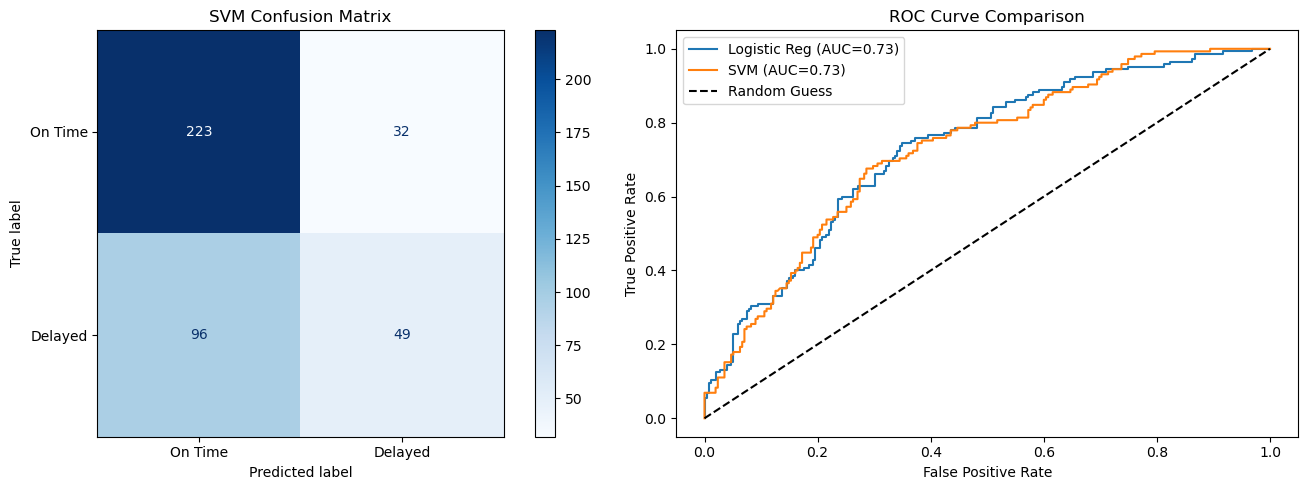

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix 
cm = confusion_matrix(y_test, svm_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['On Time', 'Delayed']
)
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('SVM Confusion Matrix')

# ROC Curve
lr_probs  = lr_model.predict_proba(X_test)[:, 1]
svm_probs = svm_model.predict_proba(X_test)[:, 1]

lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

axes[1].plot(lr_fpr,  lr_tpr,label=f'Logistic Reg (AUC={roc_auc_score(y_test, lr_probs):.2f})')
axes[1].plot(svm_fpr, svm_tpr,label=f'SVM (AUC={roc_auc_score(y_test, svm_probs):.2f})')
axes[1].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('../charts/chart7_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [10]:
# ── Precision Recall Report ───────────────────
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_predictions,target_names=['On Time', 'Delayed']))
print("SVM")
print(classification_report(y_test, svm_predictions,target_names=['On Time', 'Delayed']))
#Saving Best Model
os.makedirs('../models', exist_ok=True)
# Save whichever model scored higher AUC
if svm_cv_scores.mean() > lr_cv_scores.mean():
    best_model = svm_model
    best_name  = "SVM"
else:
    best_model = lr_model
    best_name  = "Logistic Regression"
joblib.dump(best_model, '../models/best_model.pkl')
print(f"\nBest model: {best_name}")
print(f"Saved to models/best_model.pkl")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

     On Time       0.71      0.83      0.76       255
     Delayed       0.57      0.40      0.47       145

    accuracy                           0.67       400
   macro avg       0.64      0.61      0.62       400
weighted avg       0.66      0.67      0.66       400

SVM
              precision    recall  f1-score   support

     On Time       0.70      0.87      0.78       255
     Delayed       0.60      0.34      0.43       145

    accuracy                           0.68       400
   macro avg       0.65      0.61      0.61       400
weighted avg       0.66      0.68      0.65       400


Best model: Logistic Regression
Saved to models/best_model.pkl
